In [1]:

import os
import glob
import math
import json
import torch
import pickle
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from scipy.stats import entropy
from collections import defaultdict
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
colors = ["#89c8e8","#caa2f4","#1f78b4","#6a3d9a","#8acc72", "#ebd57c", "#ed4437", "#fc9a9a"]
# colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colormap = 'viridis'  # 可以替换为 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'Spectral', 'cubehelix'

def get_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)
    return path

def count_files_in_folder(folder_path):
    file_count = 0
    for root, dirs, files in os.walk(folder_path):
        file_count += len(files)
    return file_count
plot_dir = 'figure'

# dataset_name = 'Criteo'
# DATASET_ID = 'criteo_x1_7b681156'

dataset_name = 'Avazu'
DATASET_ID = 'avazu_x4_3bbbc4c9'

activations = ['sigmoid', 'relu', 'tanh', 'silu', 'elu']

MODEL_NAME = 'DeepFM'
suffix = ['_avazu','_avazu_fs']
# suffix = ['_criteo', '_criteo_fs']
printed_name = suffix
printed_name = [MODEL_NAME + _ for _ in printed_name]
model_name_list = [MODEL_NAME + _ for _ in suffix]

plot_tag = ''

early_stop_patience = 0


num_field_dict = {
    'Criteo': 39, 'Avazu': 24, 'criteo_x1_small': 39,
}
num_field = num_field_dict[dataset_name]

def get_cardinality():
    path = os.path.join('data', dataset_name, DATASET_ID, 'feature_map.json')
    feature_map = json.load(open(path, 'r'))
    cardinality_list = []
    for _ in feature_map['features']:
        cardinality_list.append(list(_.values())[0].get('vocab_size', 0))
    return torch.tensor(cardinality_list)
cardinality = get_cardinality()
field_idx_sorted_by_cardinality = torch.sort(cardinality, descending=True).indices
num_field = len(cardinality)
num_interacted_field = num_field * (num_field - 1) // 2
row, col = torch.triu_indices(num_field, num_field, offset=1)
interacted_feature_cardinality = (cardinality.unsqueeze(-1) @ cardinality.unsqueeze(0))[row, col]
field_idx_sorted_by_interacted_feature_cardinality = torch.sort(interacted_feature_cardinality, descending=True).indices
log_data_split_dict = {
    'train': 0,
    'valid': 1,
    'test': 2,
}
phase = 'test'
batch_size = 20000
log_data_split = log_data_split_dict[phase]

In [15]:
torch.triu_indices(5, 5, offset=1)

tensor([[0, 0, 0, 0, 1, 1, 1, 2, 2, 3],
        [1, 2, 3, 4, 2, 3, 4, 3, 4, 4]])

In [21]:
import torch

# 示例张量
B, F, D = 2, 3, 2  # Batch size, Sequence length, Feature dimension
original_tensor = torch.randn(B, F, D)
print("Original Tensor Shape:", original_tensor.shape)

# 1. 生成 selection_indices [F, F-1]
# 对于第 k 个输出，我们需要从 F 维中移除第 k 个元素
# selection_indices[k] 将包含用于第 k 个输出的 F-1 个索引
# 例如 F=4:
# k=0: [1, 2, 3]
# k=1: [0, 2, 3]
# k=2: [0, 1, 3]
# k=3: [0, 1, 2]
k_vals = torch.arange(F, device=original_tensor.device).unsqueeze(1)  # Shape: [F, 1]
# 所有可能的 F-1 个索引位置 (0 到 F-2)
possible_indices_in_row = torch.arange(F - 1, device=original_tensor.device).unsqueeze(0)  # Shape: [1, F-1]
# 如果 possible_indices_in_row[j] >= k_vals[i], 则索引增加1，以跳过第 k_vals[i] 个元素
selection_indices = possible_indices_in_row + (possible_indices_in_row >= k_vals).long() # Shape: [F, F-1]

# 2. 扩展原始张量
# 将原始张量 T 复制 F 次，形成 [F, B, F, D] 的形状
# T_repeated[k] 是原始 T 的一个副本
T_repeated = original_tensor.unsqueeze(0).expand(F, -1, -1, -1) # Shape: [F, B, F, D]
# 或者使用 repeat: T_repeated = original_tensor.unsqueeze(0).repeat(F, 1, 1, 1)


# 3. 准备用于 gather 的索引
# idx_for_gather 的形状需要是 [F, B, F-1, D]
# 其值 idx_for_gather[k, b, l, d] 是 selection_indices[k, l]
# 它指示了对于输出[k,b,l,d]，应该从 T_repeated[k,b,:,d] 的哪个位置取值
idx_for_gather = selection_indices.view(F, 1, F - 1, 1) # Shape: [F, 1, F-1, 1]
idx_for_gather = idx_for_gather.expand(F, B, F - 1, D)   # Shape: [F, B, F-1, D]

# 4. 执行 gather 操作
# 我们从 T_repeated 的第2个维度 (原始的 F 维度) 进行收集
# output[k,b,l,d] = T_repeated[k, b, idx_for_gather[k,b,l,d], d]
result_stacked = torch.gather(T_repeated, dim=2, index=idx_for_gather) # Shape: [F, B, F-1, D]

print("\nStacked Result Tensor Shape:", result_stacked.shape)

# 如果需要一个包含 F 个 [B, F-1, D] 张量的列表
list_of_tensors = list(torch.unbind(result_stacked, dim=0))

# 打印其中一个结果进行验证
# print("\nFirst tensor in the list (shape {}):\n".format(list_of_tensors[0].shape), list_of_tensors[0])
# print("\nOriginal tensor for context (removing index 0 from F dim):\n", original_tensor[:, [j for j in range(F) if j != 0], :])

Original Tensor Shape: torch.Size([2, 3, 2])

Stacked Result Tensor Shape: torch.Size([3, 2, 2, 2])


In [22]:
original_tensor

tensor([[[ 0.8105, -0.7893],
         [ 0.2090,  0.6928],
         [ 0.2803, -0.1635]],

        [[ 0.7562,  0.2392],
         [ 1.2712,  0.1150],
         [ 0.3780, -0.9754]]])

In [31]:
test = torch.nn.Linear(10, 5)
data = torch.randn(2, 10)
test(data) - data @ test.weight.T - test.bias

tensor([[-7.4506e-09,  1.4901e-08,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],
       grad_fn=<SubBackward0>)

In [29]:
test.weight.shape

torch.Size([5, 10])

In [3]:


batch_data = None  # 替换为你的文件夹路径
batch_data_dir = os.path.join(f'figure/raw_data/{DATASET_ID}', "batch_data.pth") # 替换为你的文件夹路径
with open(os.path.join(batch_data_dir), 'rb') as handle:
    # b = pickle.load(handle)
    batch_data = pickle.load(handle)
X, Y = [], None
for data_name, data in batch_data[0].items():
    if data_name in ['label', 'click', 'Label']:
        Y = data.long()
    else:
        X.append(data)
X = torch.stack(X, dim=1)
field_idx_sorted_by_cardinality = torch.sort(cardinality, descending=True).indices
print(cardinality)
print(X.shape)

"""
Field cardinalities of Avazu:
tensor([     26,       9,       9,    4051,    5461,      27,    6545,     400,
             33,  820509, 2903322,    7259,       7,       6,    2556,      10,
             11,     434,       6,      70,     173,      62,       9,       4])
"""

tensor([     26,       9,       9,    4051,    5461,      27,    6545,     400,
             33,  820509, 2903322,    7259,       7,       6,    2556,      10,
             11,     434,       6,      70,     173,      62,       9,       4])
torch.Size([50000, 24])


'\nField cardinalities of Avazu:\ntensor([     26,       9,       9,    4051,    5461,      27,    6545,     400,\n             33,  820509, 2903322,    7259,       7,       6,    2556,      10,\n             11,     434,       6,      70,     173,      62,       9,       4])\n'

In [6]:
debug = torch.tensor([     26,       9,       9,    4051,    5461,      27,    6545,     400,
             33,  820509, 2903322,    7259,       7,       6,    2556,      10,
             11,     434,       6,      70,     173,      62,       9,       4])
torch.sort(debug, descending=False)

torch.return_types.sort(
values=tensor([      4,       6,       6,       7,       9,       9,       9,      10,
             11,      26,      27,      33,      62,      70,     173,     400,
            434,    2556,    4051,    5461,    6545,    7259,  820509, 2903322]),
indices=tensor([23, 18, 13, 12,  1, 22,  2, 15, 16,  0,  5,  8, 21, 19, 20,  7, 17, 14,
         3,  4,  6, 11,  9, 10]))

In [57]:
def count_files_in_folder(folder_path):
    file_count = 0
    for root, dirs, files in os.walk(folder_path):
        file_count += len(files)
    return file_count
emb_list = []
grad_list = []
emb_list_all = []

for model_name in model_name_list:
    emb_dir = os.path.join(f'figure/raw_data/{DATASET_ID}/{model_name}/', "emb")
    file_count = count_files_in_folder(emb_dir)
    emb_list_all.append([])
    with open(os.path.join(emb_dir, f'emb_epoch0.pth'), 'rb') as handle:
        emb_dict = pickle.load(handle)
        if 'grad' in emb_dict:
            grad_list.append(emb_dict.pop('grad'))
        emb_dict = {k: v.cpu() for k, v in emb_dict.items()}
        # emb_dict = {k: torch.chunk(v, 3)[log_data_split] for k, v in emb_dict.items()}
        emb_list_all[-1].append(emb_dict)
        emb_list.append(emb_dict)

# Spectrum

#### Definition of utility functions

In [9]:
def singular_value_sum(S):
    return S.sum(-1)


def condition_number(S):
    return S.max(-1).values / S.min(-1).values

def information_abundance(S):
    return S.sum(-1) / S.max(-1).values

def singular_value_variance(S):
    return (S).var(-1)

def normalized_singular_value_variance(S):
    return (S / S.mean(-1, keepdim=True)).var(-1)

def get_cov(data):
    m = data.mean(0, keepdim=True)
    rst = (data - m).T @ (data - m) / len(data)
    return rst

def uniformity(x):
    # x = F.normalize(x, dim=-1)
    return torch.pdist(x, p=2).pow(2).mul(-2).exp().mean().log()

def transform_dcnv3_emb(emb : torch.Tensor):
    B, H, D = emb.shape
    a, b = torch.tensor_split(emb, 2, dim=-1)
    a, b = a.reshape(B, H, num_field, D // 2 // num_field), b.reshape(B, H, num_field, D // 2 // num_field)
    tmp = torch.cat([a, b], dim=-1)
    tmp = tmp.flatten(1)
    return tmp

def RankMe(Z, epsilon=1.0e-7):
    # Z: [..., B, D]
    S = torch.svd(Z).S
    p_vector = S / S.sum(-1, keepdim=True) + epsilon
    rst = torch.exp((- p_vector * torch.log(p_vector)).sum(-1))
    return rst

def SVS_threshold(S, threshold=0.98):
    threshold = threshold * S.sum()
    rst = 0
    for idx, _ in enumerate(S):
        rst += _
        if rst >= threshold:
            break
    return idx

def off_diagonal(x):
    # return a flattened view of the off-diagonal elements of a square matrix
    n, m = x.shape
    assert n == m
    return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

#### Singular value sum / field cardinality

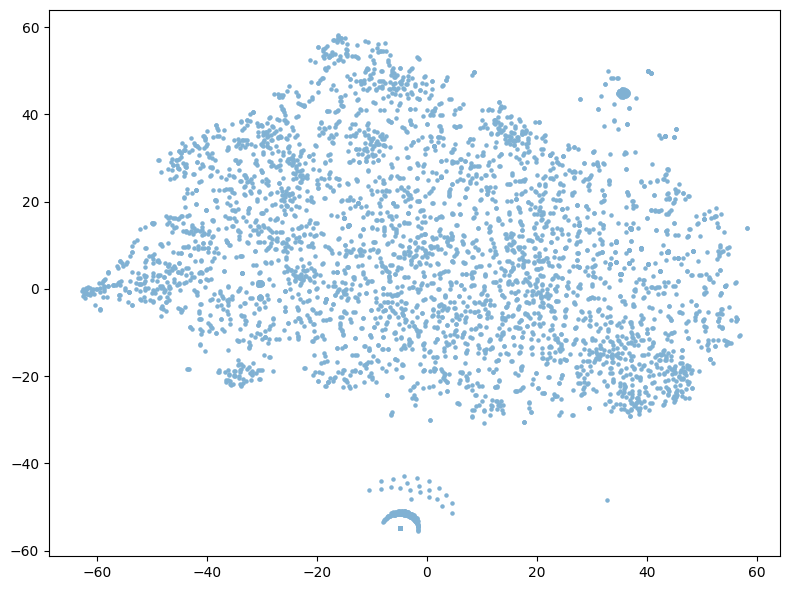

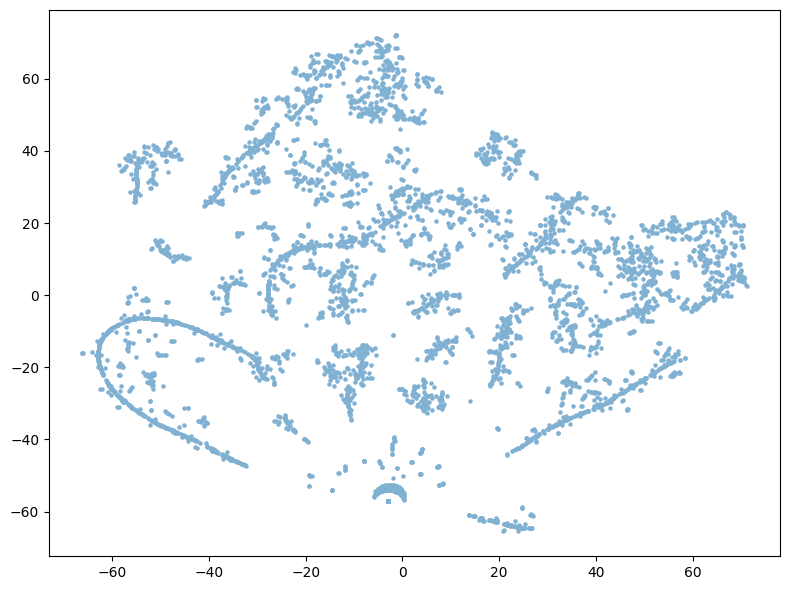

In [62]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

colors = ["#fbb463","#80b1d3","#f47f72","#bdbadb","#fbf8b4", "#8dd1c6"]
n_sample = 5000
field_idx = 10 # 10, 23
selected_idx = torch.randperm(batch_size)[:n_sample] + 0 * n_sample
label = X[selected_idx, field_idx].int() - 1
label = Y[selected_idx]
color = [colors[_] for _ in label]
l, r = 16 * field_idx, 16 * (field_idx + 1)
for idx, emb in enumerate(emb_list):
    from sklearn.manifold import TSNE
    # data = emb['X_0'].flatten(1).tensor_split(5)[0][selected_idx, l:r]
    data = emb['gating'].flatten(1)[selected_idx, l:r]
    # 使用 t-SNE 降维
    tsne = TSNE(n_components=2)
    data_tsne = tsne.fit_transform(data.numpy())  # 将 PyTorch tensor 转换为 NumPy 数组

    # 绘制 t-SNE 结果
    plt.figure(figsize=(8, 6))
    plt.scatter(data_tsne[:n_sample, 0], data_tsne[:n_sample, 1], alpha=1, s=5, color=colors[1])
    # plt.scatter(data_tsne[:n_sample, 0], data_tsne[:n_sample, 1])
    save_dir = f'./{plot_dir}/final/tsne/{dataset_name}/{MODEL_NAME}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'{field_idx}_{printed_name[idx]}.jpg'))
    plt.show()

In [7]:
def count_files_in_folder(folder_path):
    file_count = 0
    for root, dirs, files in os.walk(folder_path):
        file_count += len(files)
    return file_count
para_list = []

for model_name in model_name_list:
    emb_dir = f'model_zoo/DeepFM/Avazu/DeepFM_avazu_x4_001/avazu_x4_3bbbc4c9/{model_name}.model'
    para_list.append(torch.load(emb_dir, map_location='cpu'))
para_name_list = list(para_list[0].keys())

/tmp/ipykernel_3016115/3042271485.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 4))


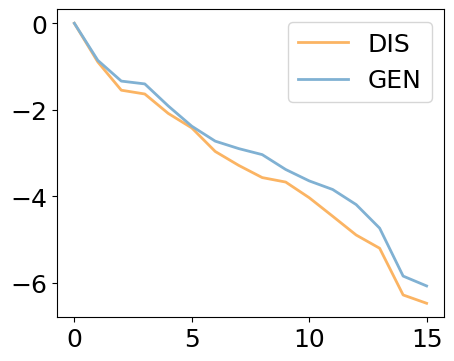

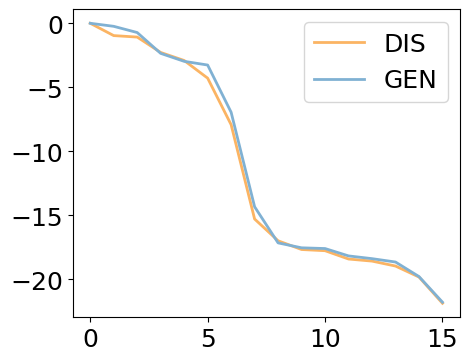

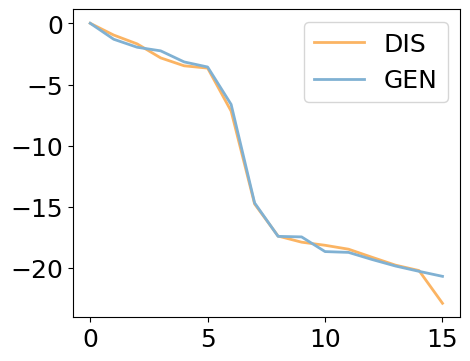

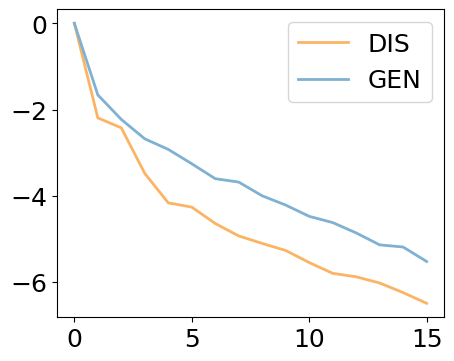

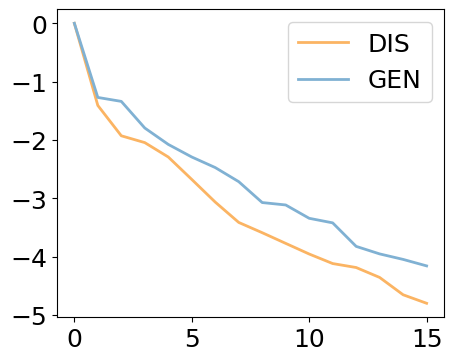

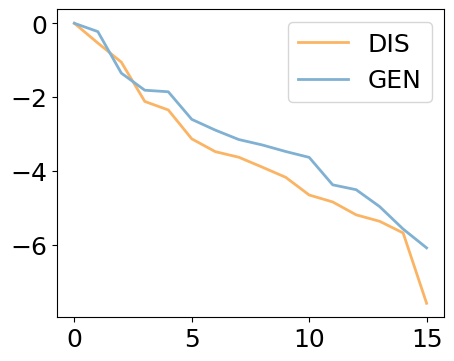

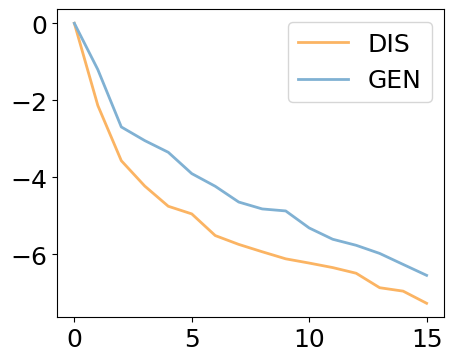

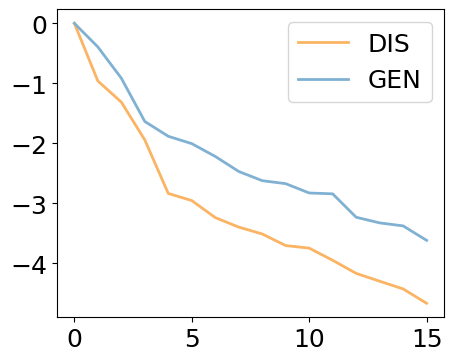

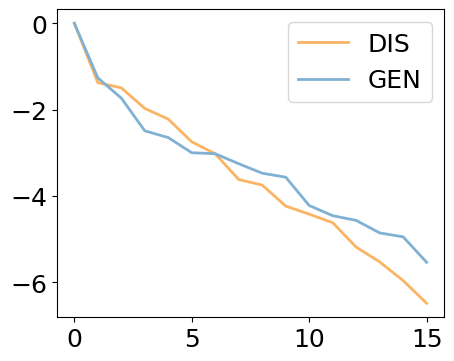

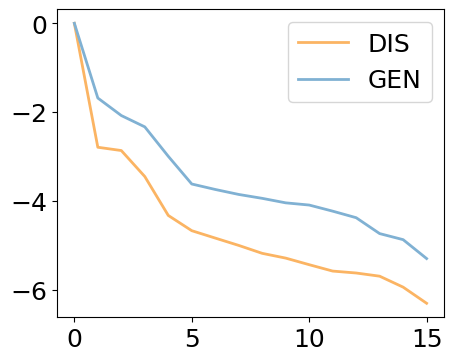

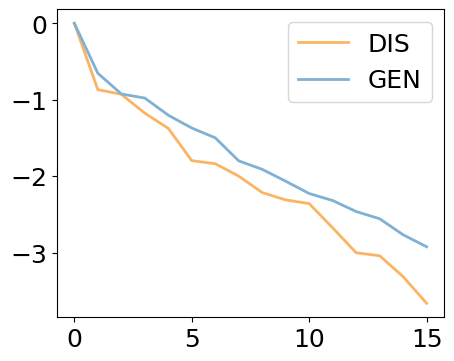

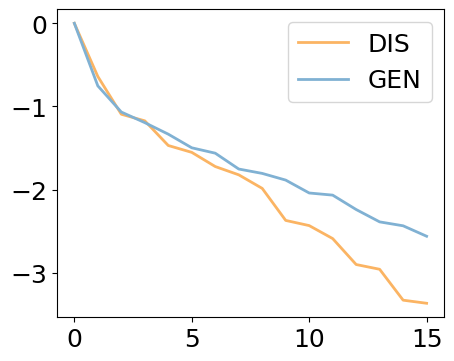

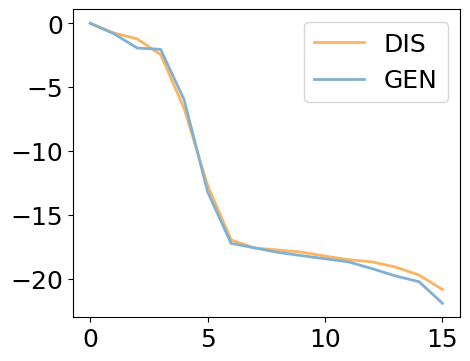

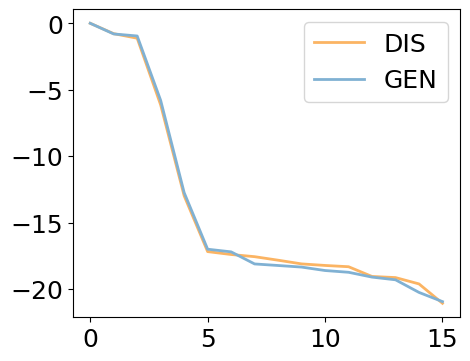

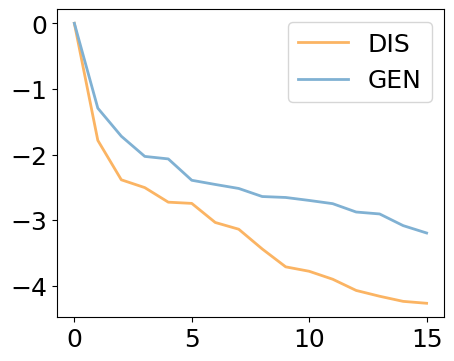

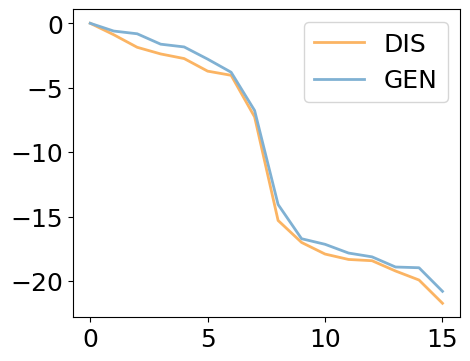

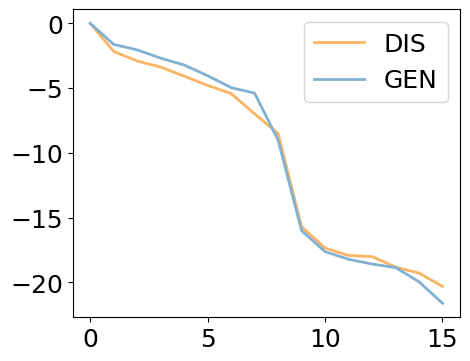

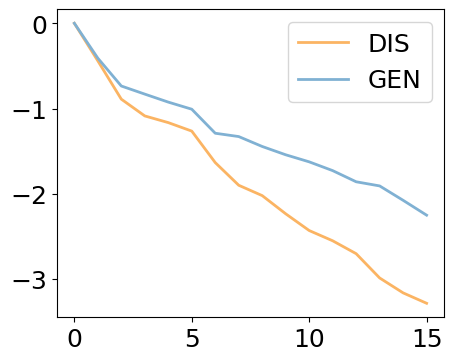

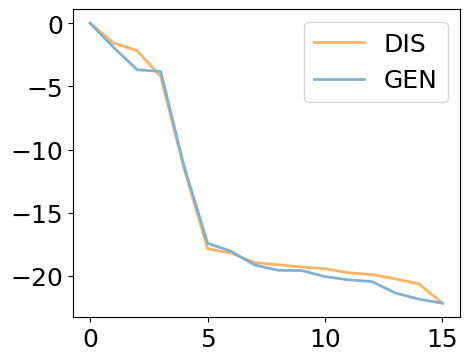

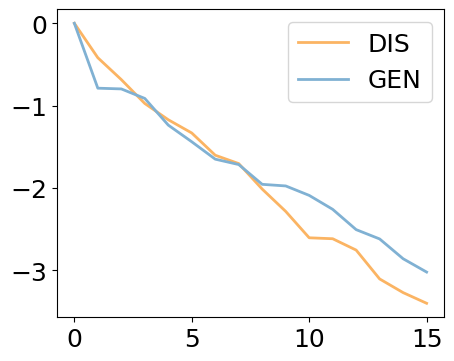

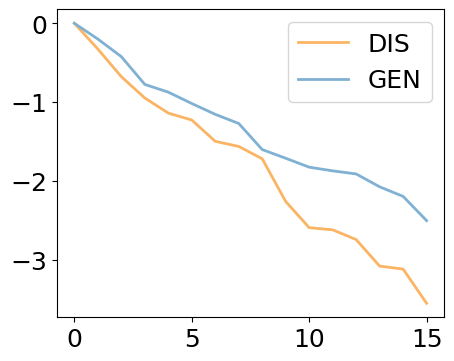

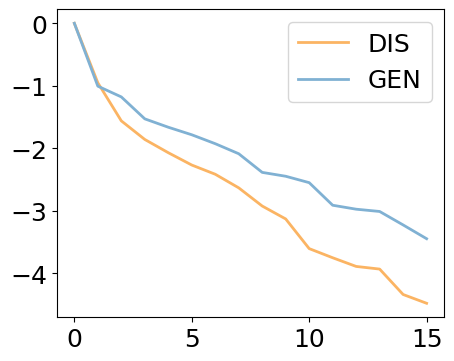

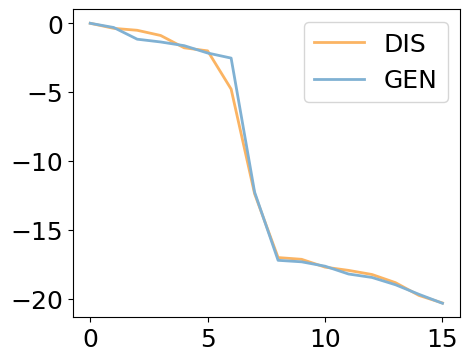

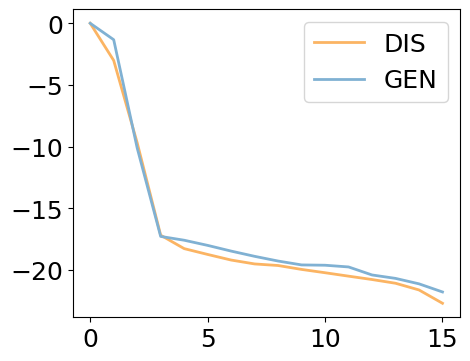

In [12]:
plt.rcParams['font.size'] = 18
colors = ["#fbb463","#80b1d3","#f47f72","#bdbadb","#fbf8b4", "#8dd1c6"]
field_idx = 2
variants = ['DIS', 'GEN']
for field_idx in range(num_field):
    fig, ax = plt.subplots(figsize=(5, 4))
    for idx, para in enumerate(para_list):
        model_name = printed_name[idx]
        y = para[para_name_list[field_idx]]
        y = get_cov(y)
        y = torch.svd(y).S
        y = y / y.max()
        y = y.log()
        x = list(range(len(y)))
        ax.plot(x, y, label=variants[idx], c=colors[idx], lw=2)
    ax.legend()
    save_dir = f'./{plot_dir}/final/per_field/{dataset_name}/'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    fig.savefig(f'./{plot_dir}/final/per_field/{dataset_name}/{model_name}_{field_idx}.jpg')